In [1]:
import sys 

sys.path.append("../../src/")
from project_imports import *



In [2]:
import defect_projector as dp
import numerical_quenches as nq 
import general_projectors as gp

from numerical_quenches import groundstate
from general_projectors import P_generic
from defect_projector import Px_n_down as P_defect

In [3]:
def free_evo_states(tau, gf, g0, L):

    tf = tau*(1-gf)

    # ramp from 0 to tf
    t_eval_quench = linspace(0, tf, 2)
    args = (tau, tf)

    states_quench = nq.states(L, t_eval_quench,
                              nq.g_linear_hold, args)

    # free evolution continues in absolute time
    t_eval_free = linspace(tf, tf + 2*np.pi, 100)

    states_free = nq.states(L, t_eval_free,
                            nq.g_linear_hold, args,
                            states_quench[-1])

    return states_free, t_eval_free

def P_defect_vector(n,sites,states):
    return array([P_defect(n,sites,s) for s in states])
def P_tilted_vector(n,nhat,states):
    return array([ P_generic(n,nhat,s) for s in states])

In [4]:
# import analytical_quench_states as kz
# taus_Q= np.logspace(-1.5,3,100)
# psi_quench_states= [kz.state(100,tau,tau) for tau in taus_Q]

In [99]:
taus_free = [0.001, 1, 10, 30]
g0s = [30, 10, 5, 5]
gfs = [0.5, 0.25, 0.1, 0.05]
L = 600

free_states = {}
free_times = {}

for tau, g0 in zip(taus_free, g0s):
    for gf in gfs:

        states, t_eval = free_evo_states(tau, gf, g0, L)

        free_states[(tau, gf)] = states
        free_times[(tau, gf)] = t_eval

g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044
g0=1.0
g0=0.5
g0=1.0
g0=0.25
g0=1.0
g0=0.09999999999999998
g0=1.0
g0=0.050000000000000044


In [ ]:
nhat = [sqrt(1-.1), sqrt(.1)]
sites = [0,2,4,6,8]

dat = {}

for (tau, gf), states_j in free_states.items():
    dat[(tau, gf)] = array([
        P_defect_vector(n, [400], states_j)
        for n in ns
    ])

print("Done!")

Done!


In [93]:
# build dat and dat_defect for all j so you can do dat[j] and dat_defect[j]
nhat= [sqrt(1-.1), sqrt(.1)]
sites= [0,2,4,6,8]
dat = [array([P_defect_vector(n, [400], states_j) for n in ns]) for states_j in free_states]
print("Done!")
dat_defect = [array([P_defect_vector(n, sites, states_j) for n in ns]) for states_j in free_states]
print("Done!")

Done!
Done!


In [94]:

dat_tilted = [array([P_tilted_vector(n, nhat, states_j) for n in ns]) for states_j in free_states]
print("Done!")

Done!


In [95]:
alt_colors= ["blue","orange","green","red"]

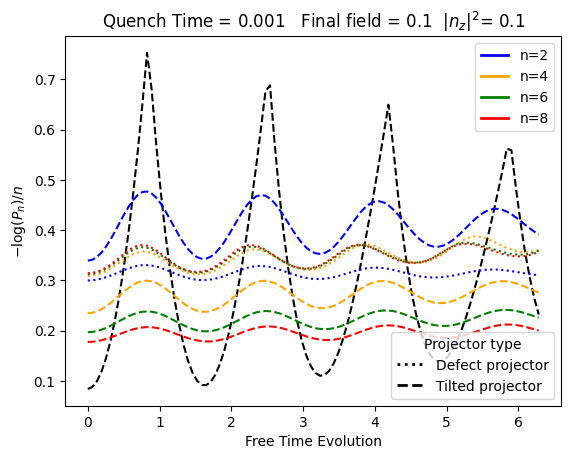

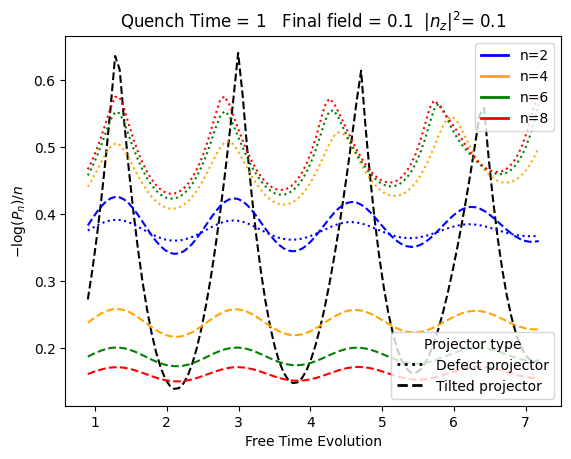

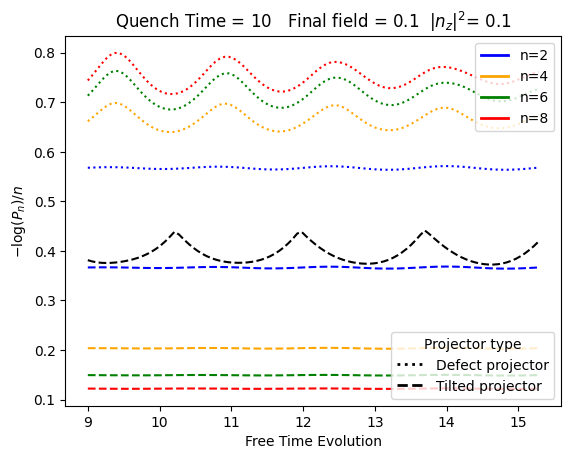

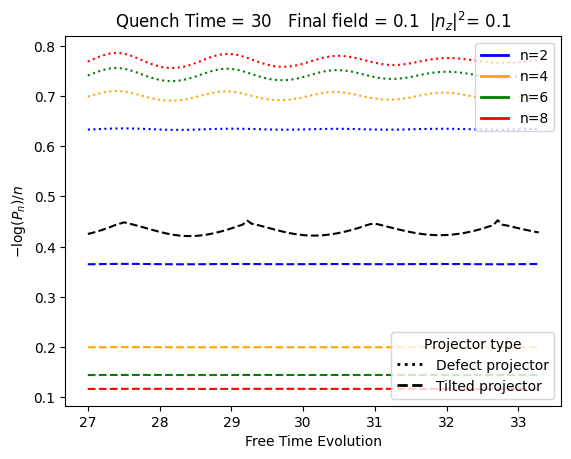

In [96]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

for j, tau in enumerate(taus_free):

    t = free_times[j]
    p_for_ns = dat[j]
    p_defect_for_ns = dat_defect[j]
    p_tilted = dat_tilted[j]
    free_state_j = free_states[j]

    plt.plot(t, -np.log(nq.overlap(free_state_j, groundstate(g0,L)))/L, "--k",label= "LE")
    #plt.plot(t, -np.log(nq.overlap(free_state_j, free_state_j[0]))/L, "k")

    for p, pd, pt, color,n in zip(p_for_ns, p_defect_for_ns, p_tilted, alt_colors,ns):
       # plt.plot(t, log(np.real(p))/n+3/4, color=color)           # full
        plt.plot(t, -log(pd)/n/4, ls=":", color=color) # defect
        plt.plot(t, -log(pt)/n, ls="--", color=color) # tilted

    # ----- legend for n (colors) -----
    color_handles = [
        Line2D([0],[0], color=c, lw=2, label=f"n={n}")
        for c, n in zip(alt_colors, ns)
    ]
    leg1 = plt.legend(handles=color_handles, loc="upper right")

    # ----- legend for projector type (linestyle) -----
    style_handles = [
       # Line2D([0],[0], color="k", lw=2, ls="-",  label="Full projector"),
        Line2D([0],[0], color="k", lw=2, ls=":", label="Defect projector"),
        Line2D([0],[0], color="k", lw=2, ls="--", label="Tilted projector"),
    ]
    leg2 = plt.legend(handles=style_handles, title="Projector type", loc="lower right")

    plt.gca().add_artist(leg1)
    xlabel("Free Time Evolution")
    ylabel(r"$-\log (P_n)/n $")
    plt.title(rf"Quench Time = {tau}   Final field = {gf}  $|n_z|^2$= {str(nhat[1]**2)[:4]}")
    plt.show()